In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [58]:
df = pd.read_csv(r"C:\Users\prana\OneDrive\Desktop\Pranav Projects\Jupiter\RabTech-Data-Analytics-Internship\Task-03-Data-Cleaning\cleaned_retail_store_sales.csv")

In [59]:
df.head()

,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,transaction_date,discount_applied,total_sales,year,month,month_name,day,day_name
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,185.0,2024,4,April,8,Monday
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,261.0,2023,7,July,23,Sunday
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,43.0,2022,10,October,5,Wednesday
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN,247.5,2022,5,May,7,Saturday
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,87.5,2022,10,October,2,Sunday


In [60]:
df.columns

Index(['transaction_id', 'customer_id', 'category', 'item', 'price_per_unit',
       'quantity', 'total_spent', 'payment_method', 'location',
       'transaction_date', 'discount_applied', 'total_sales', 'year', 'month',
       'month_name', 'day', 'day_name'],
      dtype='str')

In [61]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 12575
Columns: 17


In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    12575 non-null  str    
 1   customer_id       12575 non-null  str    
 2   category          12575 non-null  str    
 3   item              11362 non-null  str    
 4   price_per_unit    11966 non-null  float64
 5   quantity          12575 non-null  float64
 6   total_spent       11971 non-null  float64
 7   payment_method    12575 non-null  str    
 8   location          12575 non-null  str    
 9   transaction_date  12575 non-null  str    
 10  discount_applied  8376 non-null   object 
 11  total_sales       11966 non-null  float64
 12  year              12575 non-null  int64  
 13  month             12575 non-null  int64  
 14  month_name        12575 non-null  str    
 15  day               12575 non-null  int64  
 16  day_name          12575 non-null  str    
dtypes: f

In [63]:
df.describe()

,price_per_unit,quantity,total_spent,total_sales,year,month,day
count,11966.000000,12575.000000,11971.000000,11966.000000,12575.000000,12575.000000,12575.000000
mean,23.365912,5.558648,129.652577,130.226851,2023.042386,6.366441,15.633002
std,10.743519,2.790160,94.750697,93.435723,0.855581,3.503156,8.803184
min,5.000000,1.000000,5.000000,5.000000,2022.000000,1.000000,1.000000
25%,14.000000,3.000000,51.000000,52.000000,2022.000000,3.000000,8.000000
50%,23.000000,6.000000,108.500000,110.000000,2023.000000,6.000000,15.000000
75%,33.500000,8.000000,192.000000,192.000000,2024.000000,9.000000,23.000000
max,41.000000,10.000000,410.000000,410.000000,2025.000000,12.000000,31.000000


In [64]:
missing = df.isnull().sum()

print(missing)

transaction_id         0
customer_id            0
category               0
item                1213
price_per_unit       609
quantity               0
total_spent          604
payment_method         0
location               0
transaction_date       0
discount_applied    4199
total_sales          609
year                   0
month                  0
month_name             0
day                    0
day_name               0
dtype: int64


In [65]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percent
})

missing_summary

,Missing Values,Missing Percentage
transaction_id,0,0.000000
customer_id,0,0.000000
category,0,0.000000
item,1213,9.646123
price_per_unit,609,4.842942
quantity,0,0.000000
total_spent,604,4.803181
payment_method,0,0.000000
location,0,0.000000
transaction_date,0,0.000000


In [66]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [67]:
numeric_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(list(numeric_columns))

Numerical columns:
['price_per_unit', 'quantity', 'total_spent', 'total_sales', 'year', 'month', 'day']


In [68]:
df[numeric_columns].describe()

,price_per_unit,quantity,total_spent,total_sales,year,month,day
count,11966.000000,12575.000000,11971.000000,11966.000000,12575.000000,12575.000000,12575.000000
mean,23.365912,5.558648,129.652577,130.226851,2023.042386,6.366441,15.633002
std,10.743519,2.790160,94.750697,93.435723,0.855581,3.503156,8.803184
min,5.000000,1.000000,5.000000,5.000000,2022.000000,1.000000,1.000000
25%,14.000000,3.000000,51.000000,52.000000,2022.000000,3.000000,8.000000
50%,23.000000,6.000000,108.500000,110.000000,2023.000000,6.000000,15.000000
75%,33.500000,8.000000,192.000000,192.000000,2024.000000,9.000000,23.000000
max,41.000000,10.000000,410.000000,410.000000,2025.000000,12.000000,31.000000


In [69]:
statistics = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Standard Deviation": df[numeric_columns].std(),
    "Minimum": df[numeric_columns].min(),
    "Q1": df[numeric_columns].quantile(0.25),
    "Q3": df[numeric_columns].quantile(0.75),
    "Maximum": df[numeric_columns].max()
})

statistics

,Mean,Median,Standard Deviation,Minimum,Q1,Q3,Maximum
price_per_unit,23.365912,23.0,10.743519,5.0,14.0,33.5,41.0
quantity,5.558648,6.0,2.790160,1.0,3.0,8.0,10.0
total_spent,129.652577,108.5,94.750697,5.0,51.0,192.0,410.0
total_sales,130.226851,110.0,93.435723,5.0,52.0,192.0,410.0
year,2023.042386,2023.0,0.855581,2022.0,2022.0,2024.0,2025.0
month,6.366441,6.0,3.503156,1.0,3.0,9.0,12.0
day,15.633002,15.0,8.803184,1.0,8.0,23.0,31.0


In [70]:
df["payment_method"].value_counts()

payment_method
Cash              4310
Digital Wallet    4144
Credit Card       4121
Name: count, dtype: int64

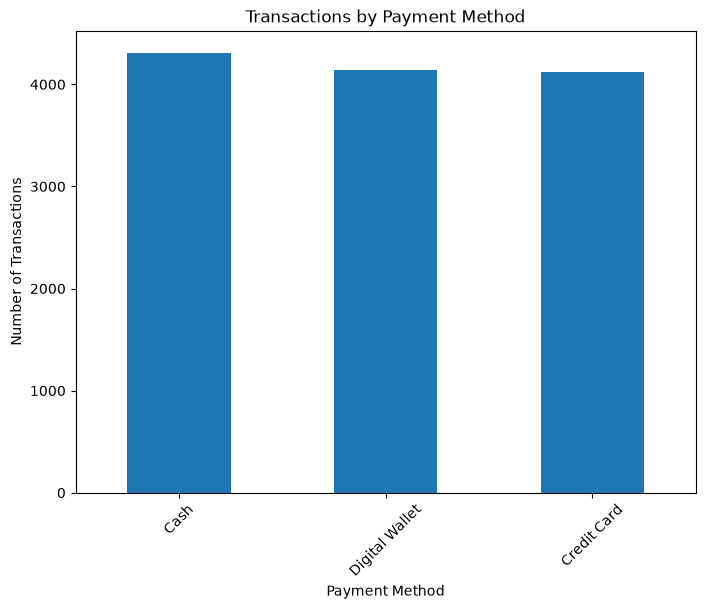

In [71]:
plt.figure(figsize=(8,6))

df["payment_method"].value_counts().plot(kind="bar")

plt.title("Transactions by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

In [72]:
df["location"].value_counts()

location
Online      6354
In-store    6221
Name: count, dtype: int64

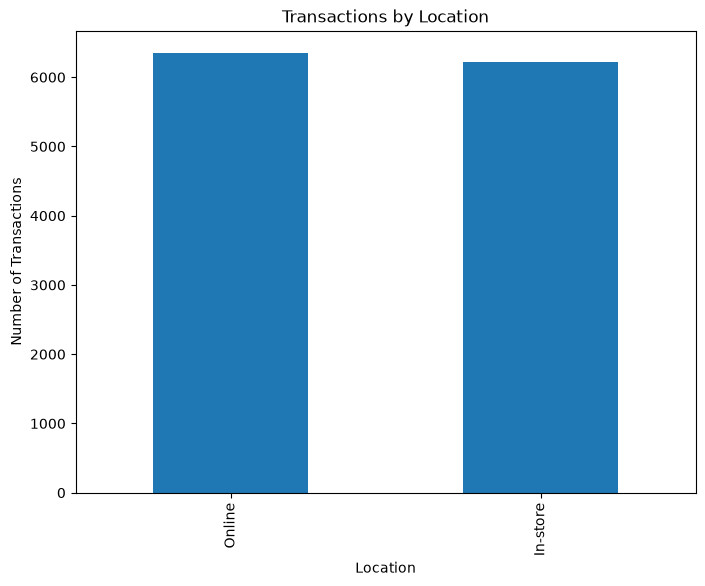

In [73]:
plt.figure(figsize=(8,6))

df["location"].value_counts().plot(kind="bar")

plt.title("Transactions by Location")
plt.xlabel("Location")
plt.ylabel("Number of Transactions")

plt.show()

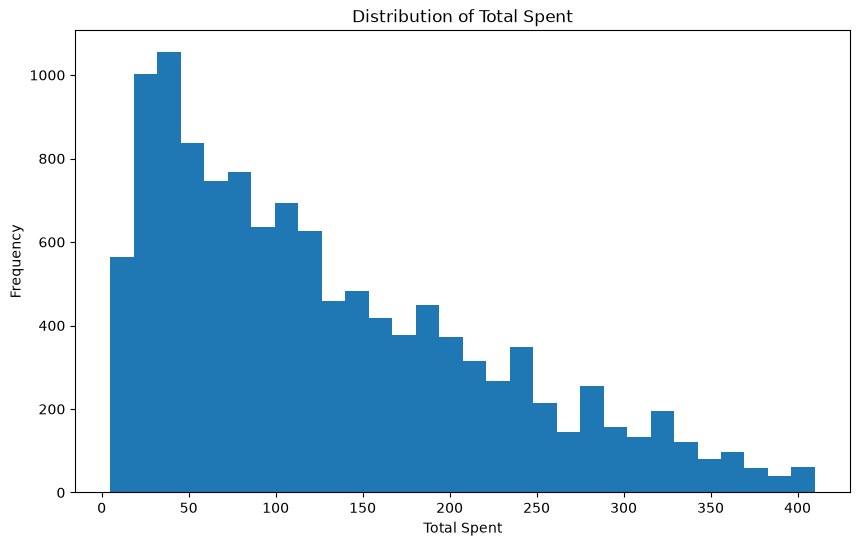

In [74]:
plt.figure(figsize=(10,6))

plt.hist(df["total_spent"], bins=30)

plt.title("Distribution of Total Spent")
plt.xlabel("Total Spent")
plt.ylabel("Frequency")

plt.show()

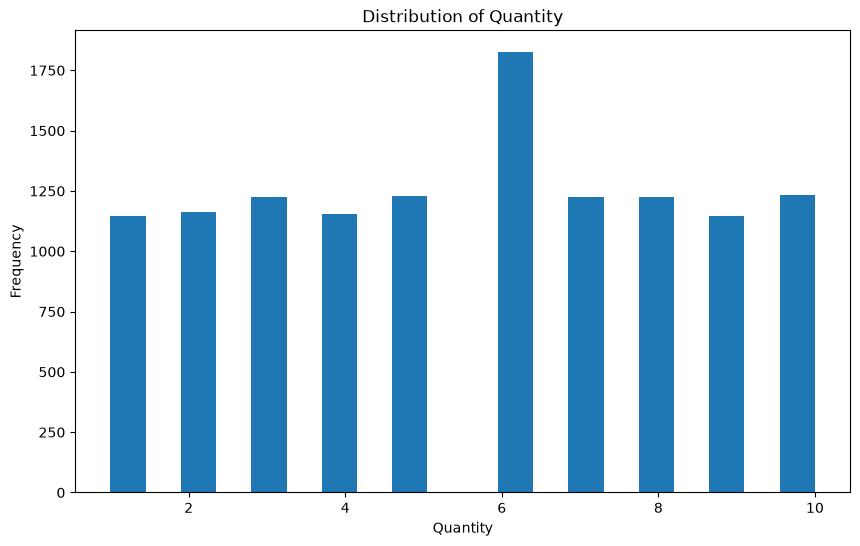

In [75]:
plt.figure(figsize=(10,6))

plt.hist(df["quantity"], bins=20)

plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

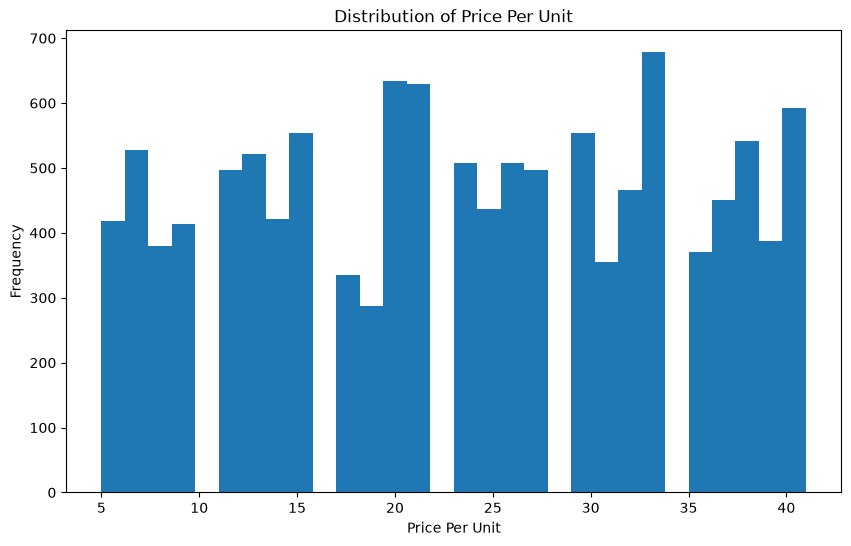

In [76]:
plt.figure(figsize=(10,6))

plt.hist(df["price_per_unit"], bins=30)

plt.title("Distribution of Price Per Unit")
plt.xlabel("Price Per Unit")
plt.ylabel("Frequency")

plt.show()

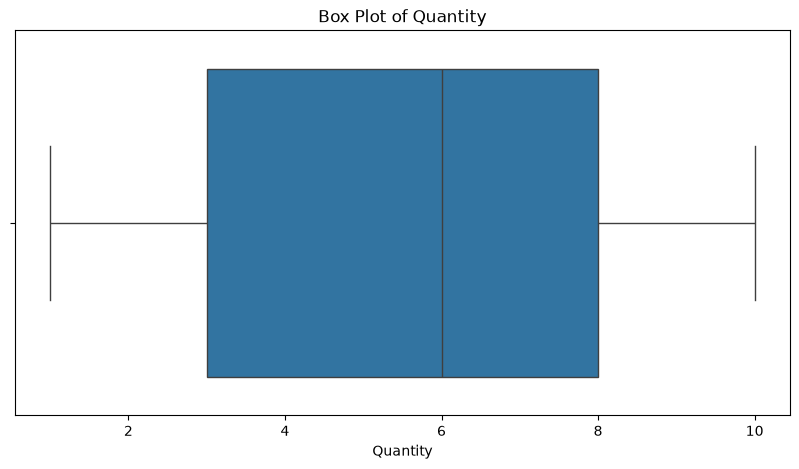

In [77]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["quantity"])

plt.title("Box Plot of Quantity")
plt.xlabel("Quantity")

plt.show()

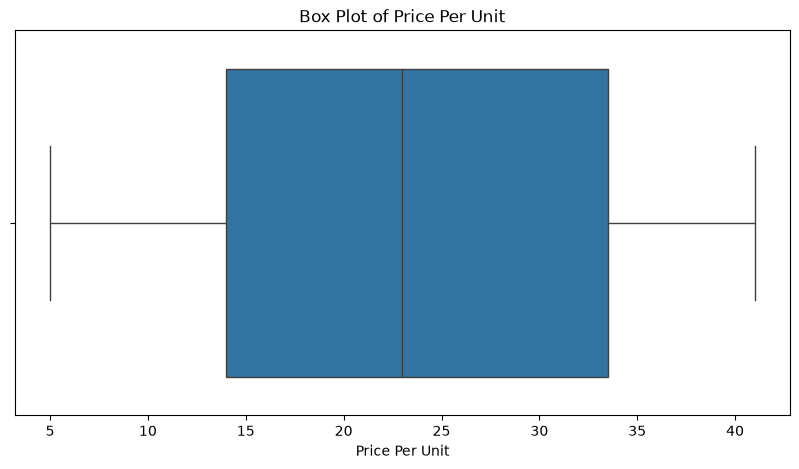

In [78]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["price_per_unit"])

plt.title("Box Plot of Price Per Unit")
plt.xlabel("Price Per Unit")

plt.show()

In [79]:
Q1 = df["total_spent"].quantile(0.25)
Q3 = df["total_spent"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["total_spent"] < lower_limit) |
    (df["total_spent"] > upper_limit)
]

print("Number of outliers:", len(outliers))

Number of outliers: 60


In [80]:
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

Lower limit: -160.5
Upper limit: 403.5


In [81]:
correlation = df[numeric_columns].corr()

correlation

,price_per_unit,quantity,total_spent,total_sales,year,month,day
price_per_unit,1.000000,0.011617,0.630902,0.642325,0.015686,-0.005001,0.005162
quantity,0.011617,1.000000,0.712069,0.704128,-0.010886,-0.010181,0.005430
total_spent,0.630902,0.712069,1.000000,1.000000,-0.001158,-0.007310,0.004494
total_sales,0.642325,0.704128,1.000000,1.000000,0.000747,-0.009058,0.007299
year,0.015686,-0.010886,-0.001158,0.000747,1.000000,-0.046390,-0.033466
month,-0.005001,-0.010181,-0.007310,-0.009058,-0.046390,1.000000,0.031465
day,0.005162,0.005430,0.004494,0.007299,-0.033466,0.031465,1.000000


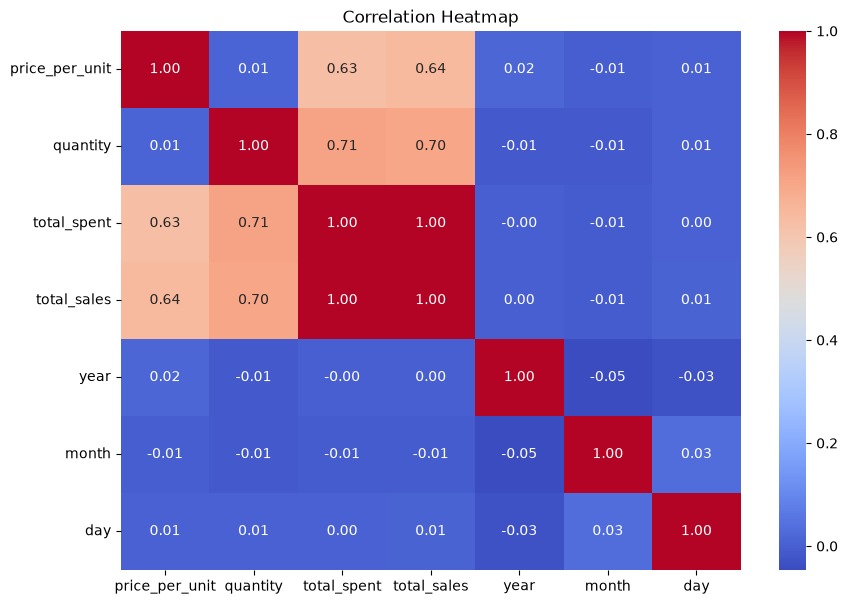

In [82]:
plt.figure(figsize=(10,7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [84]:
category_sales = df.groupby("category")["total_spent"].sum().sort_values(ascending=False)

category_sales

category
Butchers                              208118.0
Electric household essentials         203813.5
Beverages                             197047.5
Furniture                             195310.0
Food                                  194812.0
Computers and electric accessories    190692.5
Patisserie                            182165.5
Milk Products                         180112.0
Name: total_spent, dtype: float64

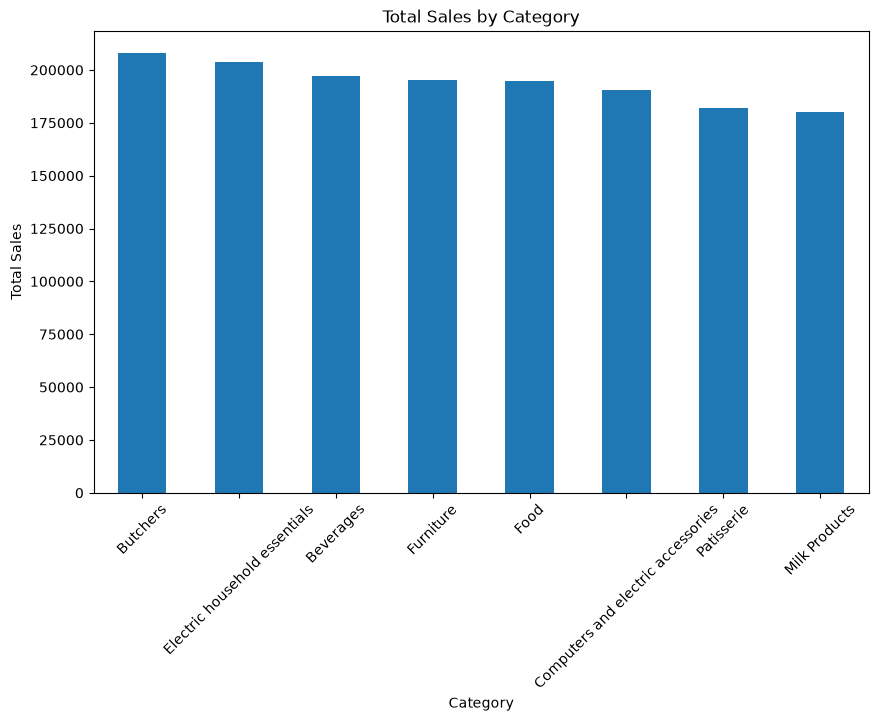

In [85]:
plt.figure(figsize=(10,6))

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

In [89]:
unique_customers = df["customer_id"].nunique()

print("Unique Customers:", unique_customers)

Unique Customers: 25


In [ ]:
customer_transactions = df.groupby("customer_id").size().sort_values(ascending=False)

customer_transactions.head(10)

In [90]:
customer_sales = df.groupby("customer_id")["total_spent"].sum().sort_values(ascending=False)

customer_sales.head(10)

customer_id
CUST_24    68452.0
CUST_08    67351.5
CUST_05    66974.5
CUST_16    65570.5
CUST_13    65037.0
CUST_23    64507.0
CUST_10    63155.5
CUST_15    63117.5
CUST_21    62933.0
CUST_02    62046.5
Name: total_spent, dtype: float64

In [91]:
quantity_sales_corr = df["quantity"].corr(df["total_spent"])

print("Correlation between Quantity and Total Spent:",
      round(quantity_sales_corr, 3))

Correlation between Quantity and Total Spent: 0.712


In [92]:
category_sales = df.groupby("category")["total_spent"].sum()

category_sales

category
Beverages                             197047.5
Butchers                              208118.0
Computers and electric accessories    190692.5
Electric household essentials         203813.5
Food                                  194812.0
Furniture                             195310.0
Milk Products                         180112.0
Patisserie                            182165.5
Name: total_spent, dtype: float64

In [ ]:
df["location"].value_counts()

In [93]:
location_sales = df.groupby("location")["total_sales"].agg(
    ["count", "sum", "mean"]
)

location_sales

,count,sum,mean
location,,,
In-store,5935,768342.5,129.459562
Online,6031,789952.0,130.981927


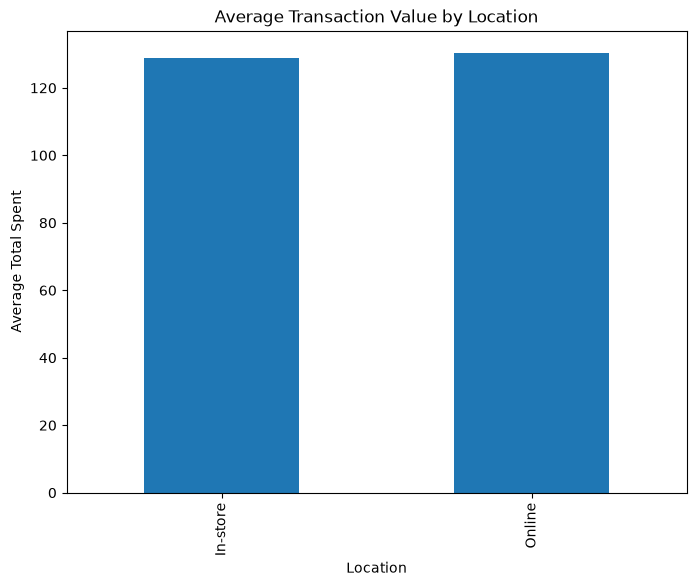

In [94]:
plt.figure(figsize=(8,6))

df.groupby("location")["total_spent"].mean().plot(kind="bar")

plt.title("Average Transaction Value by Location")
plt.xlabel("Location")
plt.ylabel("Average Total Spent")

plt.show()